<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/nn_practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Redes Neuronales con PyTorch
## Deep Learning — UTEC

---

**Objetivos:**
- Entender los fundamentos de PyTorch (tensores, autograd, `nn.Module`)
- Implementar una red neuronal para clasificación binaria desde cero
- Verificar numéricamente el forward pass y la retropropagación
- Evaluar el modelo en un conjunto de test

## Sección 0: Introducción a PyTorch

---

### 0.1 Tensores

Un **tensor** es el bloque fundamental de PyTorch: un arreglo N-dimensional de números. Es análogo a los arrays de NumPy, pero con soporte para GPU y diferenciación automática.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Crear tensores
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([[1.0, 2.0], [3.0, 4.0]])  # matriz 2x2

print('Vector:', a)
print('Forma:', a.shape)
print('Matriz:', b)
print('Forma:', b.shape)

Vector: tensor([1., 2., 3.])
Forma: torch.Size([3])
Matriz: tensor([[1., 2.],
        [3., 4.]])
Forma: torch.Size([2, 2])


In [2]:
# Operaciones con tensores
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print('Suma elemento a elemento:', x + y)
print('Multiplicación de matrices (matmul):'); print(x @ y)  # equivalente a torch.matmul(x, y)
print('Multiplicación elemento a elemento:', x * y)  # Hadamard

Suma elemento a elemento: tensor([[ 6.,  8.],
        [10., 12.]])
Multiplicación de matrices (matmul):
tensor([[19., 22.],
        [43., 50.]])
Multiplicación elemento a elemento: tensor([[ 5., 12.],
        [21., 32.]])


### 0.2 Autograd — Diferenciación Automática

PyTorch puede calcular automáticamente las derivadas de cualquier función. Esto es lo que hace posible la retropropagación sin programarla a mano.

Para que un tensor participe en el grafo de cómputo, debe tener `requires_grad=True`.

In [3]:
# Ejemplo simple de autograd
# Supón que tienes z = w * x + b y quieres dz/dw, dz/db
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)  # parámetro
b = torch.tensor(1.0, requires_grad=True)  # parámetro

z = w * x + b     # z = 3*2 + 1 = 7
loss = z ** 2     # loss = 49 (función de pérdida ficticia)

loss.backward()   # calcular gradientes

print(f'z = {z.item():.1f}')        # 7.0
print(f'dloss/dw = {w.grad:.1f}')  # d(z^2)/dw = 2z * dz/dw = 2*7*x = 2*7*2 = 28
print(f'dloss/db = {b.grad:.1f}')  # d(z^2)/db = 2z * dz/db = 2*7*1 = 14

z = 7.0
dloss/dw = 28.0
dloss/db = 14.0


### 0.3 Módulos y Capas con `nn.Module`

`nn.Module` es la clase base de todas las redes en PyTorch. Encapsula los parámetros y define el forward pass.

In [4]:
# Capa lineal en PyTorch
# nn.Linear(in_features, out_features) implementa z = x @ W.T + b
capa = nn.Linear(2, 3)  # 2 entradas, 3 salidas

print('Pesos W (shape):', capa.weight.shape)  # (3, 2) — PyTorch los guarda transpuestos
print('Bias b (shape):', capa.bias.shape)    # (3,)

x = torch.tensor([[0.5, 0.8]])  # 1 ejemplo, 2 features
z = capa(x)
print('Salida z:', z)

Pesos W (shape): torch.Size([3, 2])
Bias b (shape): torch.Size([3])
Salida z: tensor([[ 0.9115, -0.4638, -0.0888]], grad_fn=<AddmmBackward0>)


In [5]:
# Activaciones disponibles
relu = nn.ReLU()
sigmoid = nn.Sigmoid()

z_test = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
print('z:       ', z_test)
print('ReLU(z): ', relu(z_test))
print('Sigmoid: ', sigmoid(z_test))

z:        tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
ReLU(z):  tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
Sigmoid:  tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])


### 0.4 Definir una Red con `nn.Module`

La forma estándar de definir una red en PyTorch es heredar de `nn.Module` y definir `__init__` (arquitectura) y `forward` (cómputo).

In [6]:
class RedNeuronal(nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super().__init__()
        self.capa1 = nn.Linear(n_input, n_hidden)   # W1, b1
        self.capa2 = nn.Linear(n_hidden, n_output)  # W2, b2
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.capa1(x)       # z1 = x @ W1.T + b1
        a1 = self.relu(z1)       # a1 = ReLU(z1)
        z2 = self.capa2(a1)      # z2 = a1 @ W2.T + b2
        y_hat = self.sigmoid(z2) # y_hat = sigma(z2)
        return y_hat

# Crear una red 2 -> 4 -> 1
modelo = RedNeuronal(n_input=2, n_hidden=4, n_output=1)
print(modelo)
print('\nParámetros totales:', sum(p.numel() for p in modelo.parameters()))

RedNeuronal(
  (capa1): Linear(in_features=2, out_features=4, bias=True)
  (capa2): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Parámetros totales: 17


### 0.5 Loop de Entrenamiento en PyTorch

El ciclo completo de entrenamiento en PyTorch sigue siempre el mismo patrón:

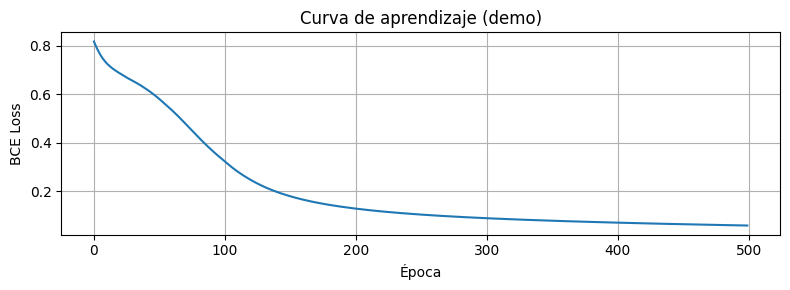

Loss inicial: 0.8170 | Loss final: 0.0588


In [7]:
# Ejemplo de loop de entrenamiento (datos ficticios)
torch.manual_seed(42)

# Datos de ejemplo
X_demo = torch.randn(20, 2)
y_demo = (X_demo[:, 0] + X_demo[:, 1] > 0).float().unsqueeze(1)  # etiqueta binaria

# Modelo, función de pérdida, optimizador
modelo_demo = RedNeuronal(2, 4, 1)
criterio = nn.BCELoss()                         # Binary Cross-Entropy
optimizador = torch.optim.SGD(modelo_demo.parameters(), lr=0.1)

losses = []
for epoca in range(500):
    # 1. Reiniciar gradientes
    optimizador.zero_grad()

    # 2. Forward pass
    y_hat = modelo_demo(X_demo)

    # 3. Calcular pérdida
    loss = criterio(y_hat, y_demo)

    # 4. Backpropagación
    loss.backward()

    # 5. Actualizar pesos
    optimizador.step()

    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Época'); plt.ylabel('BCE Loss'); plt.title('Curva de aprendizaje (demo)')
plt.grid(True); plt.tight_layout(); plt.show()
print(f'Loss inicial: {losses[0]:.4f} | Loss final: {losses[-1]:.4f}')

---
## Sección 1: Ejercicio 1 — Diagnóstico de Tumores (RESUELTO)

**Problema:** Clasificar tumores como **benigno** ($y=0$) o **maligno** ($y=1$) a partir de dos biomarcadores normalizados.

| Parámetro | Valor |
|-----------|-------|
| Entradas ($n_x$) | 2 |
| Neuronas ocultas ($n_h$) | 2 (ReLU) |
| Salida ($n_y$) | 1 (Sigmoid) |
| Entrenamiento | 10 ejemplos |
| Test | 4 ejemplos |

### 1.1 Dataset

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Dataset de entrenamiento (ya normalizado)
X_train = torch.tensor([
    [0.20, 0.10],  # Benigno (y=0)
    [0.30, 0.30],
    [0.10, 0.20],
    [0.40, 0.20],
    [0.30, 0.40],
    [0.80, 0.90],  # Maligno (y=1)
    [0.90, 0.80],
    [0.70, 0.90],
    [0.80, 0.70],
    [0.90, 0.60],
], dtype=torch.float32)

y_train = torch.tensor([[0],[0],[0],[0],[0],[1],[1],[1],[1],[1]], dtype=torch.float32)

# Dataset de test
X_test = torch.tensor([
    [0.20, 0.30],  # Benigno
    [0.40, 0.10],  # Benigno
    [0.70, 0.80],  # Maligno
    [0.90, 0.70],  # Maligno
], dtype=torch.float32)

y_test = torch.tensor([[0],[0],[1],[1]], dtype=torch.float32)

print(f'X_train shape: {X_train.shape}')  # (10, 2)
print(f'y_train shape: {y_train.shape}')  # (10, 1)
print(f'X_test shape:  {X_test.shape}')   # (4, 2)
print(f'y_test shape:  {y_test.shape}')   # (4, 1)

X_train shape: torch.Size([10, 2])
y_train shape: torch.Size([10, 1])
X_test shape:  torch.Size([4, 2])
y_test shape:  torch.Size([4, 1])


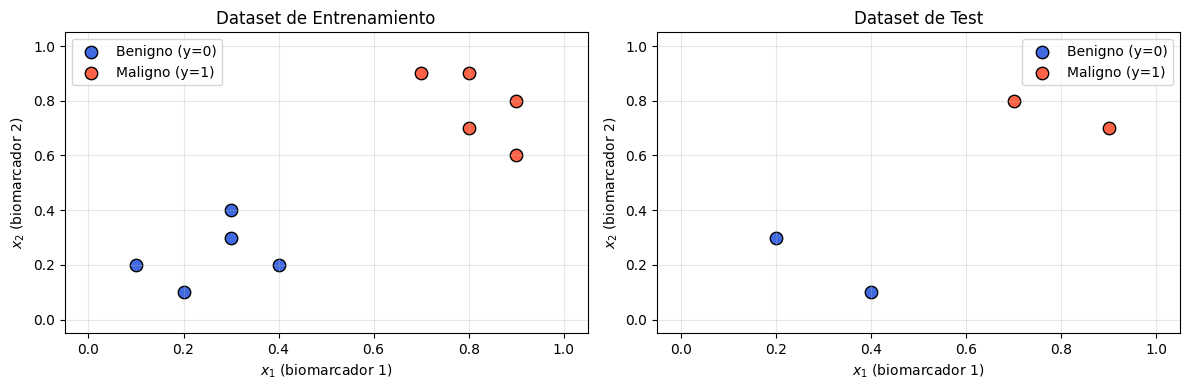

In [9]:
# Visualizar el dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X, y, title in zip(axes, [X_train, X_test], [y_train, y_test], ['Entrenamiento', 'Test']):
    mask0 = y.squeeze() == 0
    mask1 = y.squeeze() == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], c='royalblue', label='Benigno (y=0)', s=80, edgecolors='k')
    ax.scatter(X[mask1, 0], X[mask1, 1], c='tomato', label='Maligno (y=1)', s=80, edgecolors='k')
    ax.set_xlabel('$x_1$ (biomarcador 1)'); ax.set_ylabel('$x_2$ (biomarcador 2)')
    ax.set_title(f'Dataset de {title}'); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

### 1.2 Verificación Manual del Forward Pass (Época 0)

Aquí vamos a **verificar numéricamente** los cálculos del forward pass con los pesos iniciales definidos en los slides, para asegurarnos de que PyTorch hace lo mismo que hicimos a mano.

**Pesos iniciales:**
$$W^{(1)} = \begin{bmatrix}0.5 & 0.3 \\ -0.4 & 0.6\end{bmatrix}, \quad b^{(1)} = [0, 0]$$
$$W^{(2)} = \begin{bmatrix}0.7 \\ 0.4\end{bmatrix}, \quad b^{(2)} = [0]$$

In [10]:
# Definir pesos manualmente (para verificar con los slides)
W1 = torch.tensor([[0.5,  0.3],
                   [-0.4, 0.6]], dtype=torch.float32)  # (2, 2)
b1 = torch.tensor([[0.0, 0.0]], dtype=torch.float32)   # (1, 2)

W2 = torch.tensor([[0.7],
                   [0.4]], dtype=torch.float32)          # (2, 1)
b2 = torch.tensor([[0.0]], dtype=torch.float32)          # (1, 1)

# Forward pass manual
Z1 = X_train @ W1 + b1                    # (10, 2)
A1 = torch.relu(Z1)                       # (10, 2)
Z2 = A1 @ W2 + b2                         # (10, 1)
Y_hat = torch.sigmoid(Z2)                 # (10, 1)

print('Z1 (primeras 5 filas):')
print(Z1[:5].detach().numpy().round(3))
print('\nA1 = ReLU(Z1) (primeras 5 filas):')
print(A1[:5].detach().numpy().round(3))
print('\nZ2 y Y_hat (todas las filas):')
for i in range(10):
    print(f'  i={i+1:2d}: z2={Z2[i,0].item():.3f}  ŷ={Y_hat[i,0].item():.3f}  y={int(y_train[i,0].item())}')

Z1 (primeras 5 filas):
[[ 0.06  0.12]
 [ 0.03  0.27]
 [-0.03  0.15]
 [ 0.12  0.24]
 [-0.01  0.33]]

A1 = ReLU(Z1) (primeras 5 filas):
[[0.06 0.12]
 [0.03 0.27]
 [0.   0.15]
 [0.12 0.24]
 [0.   0.33]]

Z2 y Y_hat (todas las filas):
  i= 1: z2=0.090  ŷ=0.522  y=0
  i= 2: z2=0.129  ŷ=0.532  y=0
  i= 3: z2=0.060  ŷ=0.515  y=0
  i= 4: z2=0.180  ŷ=0.545  y=0
  i= 5: z2=0.132  ŷ=0.533  y=0
  i= 6: z2=0.340  ŷ=0.584  y=1
  i= 7: z2=0.391  ŷ=0.597  y=1
  i= 8: z2=0.300  ŷ=0.574  y=1
  i= 9: z2=0.348  ŷ=0.586  y=1
  i=10: z2=0.399  ŷ=0.598  y=1


In [11]:
# Calcular BCE Loss manualmente
m = X_train.shape[0]
# L = -(1/m) * sum[ y*log(yhat) + (1-y)*log(1-yhat) ]
eps = 1e-8  # evitar log(0)
L_manual = -torch.mean(y_train * torch.log(Y_hat + eps) + (1 - y_train) * torch.log(1 - Y_hat + eps))
print(f'BCE Loss (manual): {L_manual.item():.4f}')

# Verificar con nn.BCELoss
criterio = nn.BCELoss()
L_pytorch = criterio(Y_hat, y_train)
print(f'BCE Loss (PyTorch BCELoss): {L_pytorch.item():.4f}')
print(f'\nResultado esperado (slides): 0.643')

BCE Loss (manual): 0.6427
BCE Loss (PyTorch BCELoss): 0.6427

Resultado esperado (slides): 0.643


### 1.3 Definición del Modelo con `nn.Module`

In [12]:
class RedTumor(nn.Module):
    """Red neuronal 2 -> n_hidden -> 1 para clasificación binaria."""
    def __init__(self, n_hidden=2):
        super().__init__()
        self.fc1 = nn.Linear(2, n_hidden)  # Capa oculta
        self.fc2 = nn.Linear(n_hidden, 1)  # Capa de salida

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.relu(z1)
        z2 = self.fc2(a1)
        y_hat = torch.sigmoid(z2)
        return y_hat


def inicializar_pesos_manual(modelo, W1, b1, W2, b2):
    """Inicializa la red con pesos específicos (para reproducir los slides)."""
    # NOTA: nn.Linear guarda los pesos como W.T (transpuesto)
    # Si nuestro cálculo es z = x @ W1 + b1 (con W1 de forma n_in x n_out),
    # PyTorch calcula z = x @ weight.T + bias, con weight de forma n_out x n_in.
    # Por lo tanto: weight = W1.T
    with torch.no_grad():
        modelo.fc1.weight.copy_(W1.T)  # W1 es (n_in, n_out), weight es (n_out, n_in)
        modelo.fc1.bias.copy_(b1.squeeze())
        modelo.fc2.weight.copy_(W2.T)
        modelo.fc2.bias.copy_(b2.squeeze())

# Crear modelo con pesos de los slides
torch.manual_seed(0)
modelo_ej1 = RedTumor(n_hidden=2)
inicializar_pesos_manual(modelo_ej1, W1, b1, W2, b2)

# Verificar que el forward pass coincide
y_hat_modelo = modelo_ej1(X_train)
print('Comparación con cálculo manual:')
print('Modelo PyTorch vs Manual:')
for i in range(10):
    ym = y_hat_modelo[i, 0].item()
    yman = Y_hat[i, 0].item()
    coincide = '✓' if abs(ym - yman) < 1e-4 else '✗'
    print(f'  i={i+1:2d}: modelo={ym:.4f}  manual={yman:.4f}  {coincide}')

Comparación con cálculo manual:
Modelo PyTorch vs Manual:
  i= 1: modelo=0.5225  manual=0.5225  ✓
  i= 2: modelo=0.5322  manual=0.5322  ✓
  i= 3: modelo=0.5150  manual=0.5150  ✓
  i= 4: modelo=0.5449  manual=0.5449  ✓
  i= 5: modelo=0.5330  manual=0.5330  ✓
  i= 6: modelo=0.5842  manual=0.5842  ✓
  i= 7: modelo=0.5965  manual=0.5965  ✓
  i= 8: modelo=0.5744  manual=0.5744  ✓
  i= 9: modelo=0.5861  manual=0.5861  ✓
  i=10: modelo=0.5984  manual=0.5984  ✓


### 1.4 Entrenamiento

In [13]:
# Usar los pesos de los slides como punto de partida
inicializar_pesos_manual(modelo_ej1, W1, b1, W2, b2)

criterio = nn.BCELoss()
optimizador = torch.optim.SGD(modelo_ej1.parameters(), lr=0.5)

N_EPOCAS = 1000
historico_loss = []

for epoca in range(N_EPOCAS):
    modelo_ej1.train()

    # 1. Borrar gradientes acumulados
    optimizador.zero_grad()

    # 2. Forward pass
    y_hat = modelo_ej1(X_train)

    # 3. Pérdida
    loss = criterio(y_hat, y_train)

    # 4. Backpropagación
    loss.backward()

    # 5. Actualización de pesos
    optimizador.step()

    historico_loss.append(loss.item())

    if (epoca + 1) % 100 == 0:
        print(f'Época {epoca+1:4d}/{N_EPOCAS} — Loss: {loss.item():.4f}')

print(f'\nLoss inicial (época 1): {historico_loss[0]:.4f}')
print(f'Loss final (época {N_EPOCAS}): {historico_loss[-1]:.4f}')

Época  100/1000 — Loss: 0.0438
Época  200/1000 — Loss: 0.0181
Época  300/1000 — Loss: 0.0111
Época  400/1000 — Loss: 0.0079
Época  500/1000 — Loss: 0.0061
Época  600/1000 — Loss: 0.0050
Época  700/1000 — Loss: 0.0042
Época  800/1000 — Loss: 0.0036
Época  900/1000 — Loss: 0.0032
Época 1000/1000 — Loss: 0.0028

Loss inicial (época 1): 0.6427
Loss final (época 1000): 0.0028


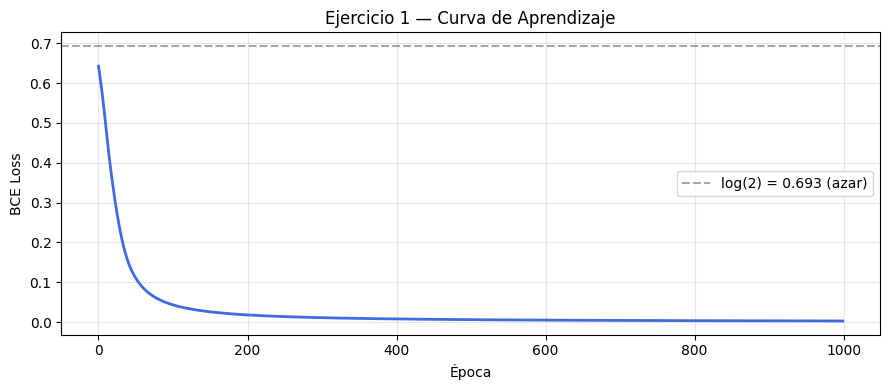

In [14]:
# Graficar la curva de aprendizaje
plt.figure(figsize=(9, 4))
plt.plot(historico_loss, color='royalblue', linewidth=2)
plt.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.7, label=f'log(2) = {np.log(2):.3f} (azar)')
plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title('Ejercicio 1 — Curva de Aprendizaje')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 1.5 Evaluación en el Test Set

In [15]:
modelo_ej1.eval()
with torch.no_grad():
    y_hat_test = modelo_ej1(X_test)
    y_pred_test = (y_hat_test >= 0.5).float()

print('Evaluación en Test Set:')
print(f'{"i":>3} | {"x1":>6} {"x2":>6} | {"y_real":>7} | {"ŷ":>7} | {"ŷ_pred":>7} | Resultado')
print('-' * 55)
correctos = 0
for i in range(len(X_test)):
    yi = int(y_test[i, 0].item())
    yh = y_hat_test[i, 0].item()
    yp = int(y_pred_test[i, 0].item())
    resultado = '✓ CORRECTO' if yp == yi else '✗ INCORRECTO'
    if yp == yi: correctos += 1
    print(f'{i+1:3d} | {X_test[i,0].item():.2f}  {X_test[i,1].item():.2f} | {yi:7d} | {yh:.4f} | {yp:7d} | {resultado}')

accuracy = correctos / len(X_test) * 100
print(f'\nAccuracy en Test: {correctos}/{len(X_test)} = {accuracy:.1f}%')

Evaluación en Test Set:
  i |     x1     x2 |  y_real |       ŷ |  ŷ_pred | Resultado
-------------------------------------------------------
  1 | 0.20  0.30 |       0 | 0.0048 |       0 | ✓ CORRECTO
  2 | 0.40  0.10 |       0 | 0.0048 |       0 | ✓ CORRECTO
  3 | 0.70  0.80 |       1 | 0.9973 |       1 | ✓ CORRECTO
  4 | 0.90  0.70 |       1 | 0.9997 |       1 | ✓ CORRECTO

Accuracy en Test: 4/4 = 100.0%


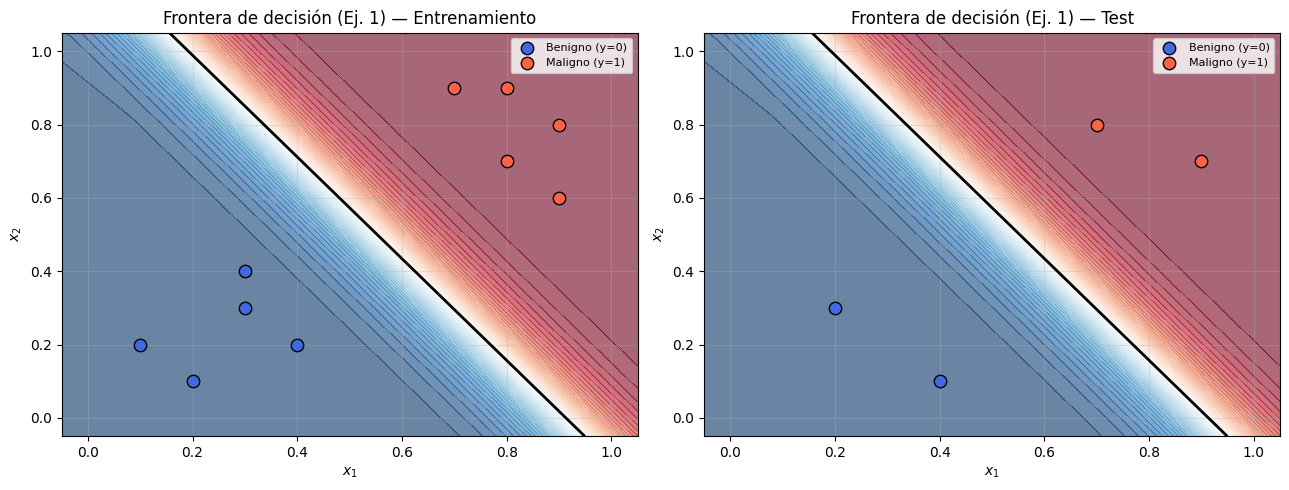

In [16]:
# Visualizar frontera de decisión
def plot_decision_boundary(model, X_train, y_train, X_test, y_test, titulo=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, X, y, subtit in zip(axes, [X_train, X_test], [y_train, y_test], ['Entrenamiento', 'Test']):
        # Crear malla de puntos
        xx, yy = np.meshgrid(np.linspace(-0.05, 1.05, 200), np.linspace(-0.05, 1.05, 200))
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            Z = model(grid).numpy().reshape(xx.shape)

        ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6, vmin=0, vmax=1)
        ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)

        y_sq = y.squeeze()
        ax.scatter(X[y_sq==0, 0], X[y_sq==0, 1], c='royalblue', s=80, edgecolors='k', label='Benigno (y=0)', zorder=5)
        ax.scatter(X[y_sq==1, 0], X[y_sq==1, 1], c='tomato', s=80, edgecolors='k', label='Maligno (y=1)', zorder=5)
        ax.set_title(f'{titulo} — {subtit}')
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

plot_decision_boundary(modelo_ej1, X_train, y_train, X_test, y_test, titulo='Frontera de decisión (Ej. 1)')

### 1.6 Verificación: Comparar PyTorch vs Cálculo Manual (1 época)

Verificamos que después de 1 sola actualización de gradiente, PyTorch produce los mismos pesos que calculamos en los slides.

In [17]:
# Re-inicializar con pesos de los slides
inicializar_pesos_manual(modelo_ej1, W1, b1, W2, b2)

optimizador_v = torch.optim.SGD(modelo_ej1.parameters(), lr=0.5)
optimizador_v.zero_grad()
y_hat_v = modelo_ej1(X_train)
loss_v = criterio(y_hat_v, y_train)
loss_v.backward()
optimizador_v.step()

# Leer pesos actualizados
W1_new_pt = modelo_ej1.fc1.weight.data.T  # (2, 2) — deshacemos la transposición
b1_new_pt = modelo_ej1.fc1.bias.data      # (2,)
W2_new_pt = modelo_ej1.fc2.weight.data.T  # (2, 1)
b2_new_pt = modelo_ej1.fc2.bias.data      # (1,)

print('=== Comparación pesos actualizados: PyTorch vs Slides ===' )
print(f'\nW1 (PyTorch):\n{W1_new_pt.numpy().round(3)}')
print(f'W1 esperado (slides):\n[[0.532, 0.320], [-0.368, 0.620]]')

print(f'\nb1 (PyTorch): {b1_new_pt.numpy().round(3)}')
print(f'b1 esperado:  [0.002, -0.012]')

print(f'\nW2 (PyTorch): {W2_new_pt.numpy().round(3).flatten()}')
print(f'W2 esperado:  [[0.705], [0.444]]')

print(f'\nb2 (PyTorch): {b2_new_pt.numpy().round(3)}')
print(f'b2 esperado:  [-0.030]')

=== Comparación pesos actualizados: PyTorch vs Slides ===

W1 (PyTorch):
[[ 0.532  0.32 ]
 [-0.368  0.619]]
W1 esperado (slides):
[[0.532, 0.320], [-0.368, 0.620]]

b1 (PyTorch): [ 0.001 -0.012]
b1 esperado:  [0.002, -0.012]

W2 (PyTorch): [0.705 0.444]
W2 esperado:  [[0.705], [0.444]]

b2 (PyTorch): [-0.029]
b2 esperado:  [-0.030]


---
## Sección 2: Ejercicio 2 — Clasificación de Crédito (PARA RESOLVER)

**Problema:** Predecir si un cliente tendrá **mora** ($y=1$) o **no** ($y=0$) basándose en dos indicadores normalizados:
- $x_1$ = ratio de deuda
- $x_2$ = historial crediticio inverso

| Parámetro | Valor |
|-----------|-------|
| Entradas ($n_x$) | 2 |
| Neuronas ocultas ($n_h$) | **3** (ReLU) |
| Salida ($n_y$) | 1 (Sigmoid) |
| Entrenamiento | **20** ejemplos |
| Test | **5** ejemplos |

---

In [18]:
# Dataset proporcionado — NO MODIFICAR
X_train_ej2 = torch.tensor([
    [0.15, 0.20], [0.25, 0.10], [0.30, 0.35], [0.10, 0.30],
    [0.40, 0.15], [0.20, 0.45], [0.35, 0.25], [0.45, 0.40],
    [0.15, 0.40], [0.50, 0.30],  # Clase 0
    [0.65, 0.70], [0.75, 0.80], [0.80, 0.70], [0.70, 0.85],
    [0.85, 0.75], [0.60, 0.90], [0.90, 0.65], [0.75, 0.65],
    [0.60, 0.80], [0.80, 0.90],  # Clase 1
], dtype=torch.float32)

y_train_ej2 = torch.tensor(
    [[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],
     [1],[1],[1],[1],[1],[1],[1],[1],[1],[1]], dtype=torch.float32)

X_test_ej2 = torch.tensor([
    [0.20, 0.30], [0.45, 0.25], [0.35, 0.45],  # Clase 0
    [0.70, 0.75], [0.85, 0.80],                 # Clase 1
], dtype=torch.float32)

y_test_ej2 = torch.tensor([[0],[0],[0],[1],[1]], dtype=torch.float32)

print(f'X_train shape: {X_train_ej2.shape}')  # (20, 2)
print(f'y_train shape: {y_train_ej2.shape}')  # (20, 1)
print(f'X_test shape:  {X_test_ej2.shape}')   # (5, 2)
print(f'y_test shape:  {y_test_ej2.shape}')   # (5, 1)

X_train shape: torch.Size([20, 2])
y_train shape: torch.Size([20, 1])
X_test shape:  torch.Size([5, 2])
y_test shape:  torch.Size([5, 1])


### Tarea 1: Visualizar el dataset

Grafica los datos de entrenamiento y test en un scatter plot. ¿Son linealmente separables?

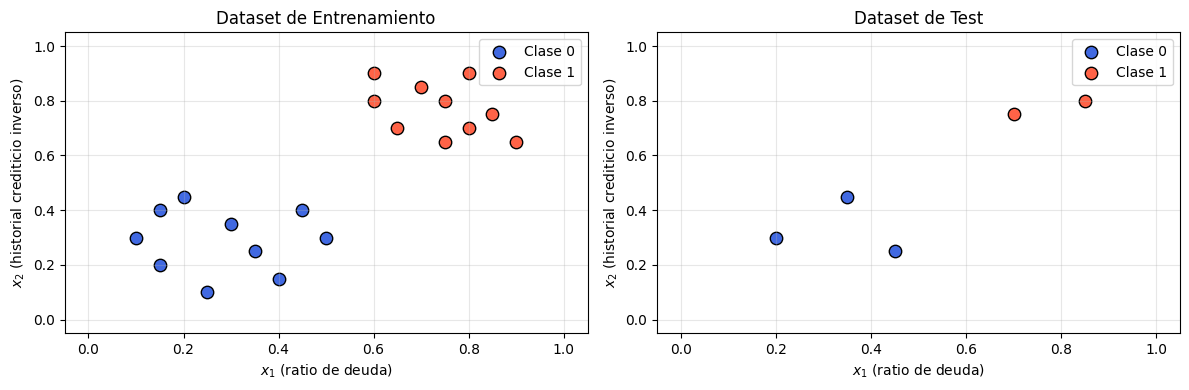

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X, y, title in zip(axes, [X_train_ej2, X_test_ej2], [y_train_ej2, y_test_ej2], ['Entrenamiento', 'Test']):
    mask0 = y.squeeze() == 0
    mask1 = y.squeeze() == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], c='royalblue', label='Clase 0', s=80, edgecolors='k')
    ax.scatter(X[mask1, 0], X[mask1, 1], c='tomato', label='Clase 1', s=80, edgecolors='k')
    ax.set_xlabel('$x_1$ (ratio de deuda)'); ax.set_ylabel('$x_2$ (historial crediticio inverso)')
    ax.set_title(f'Dataset de {title}'); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

### Tarea 2: Definir el modelo $2 \to 3 \to 1$

Define una clase `RedCredito` que herede de `nn.Module` con:
- Capa oculta: 2 → 3 neuronas, activación ReLU
- Capa de salida: 3 → 1 neurona, activación Sigmoid

¿Cuántos parámetros tiene esta red?

In [30]:
# TODO: Definir la red 2 -> 3 -> 1

class RedCredito(nn.Module):
    """Red neuronal 2 -> n_hidden -> 1 para clasificación binaria."""
    def __init__(self, n_hidden=3):
        super().__init__()
        self.fc1 = nn.Linear(2, n_hidden)  # Capa oculta: 2 entradas, 3 salidas
        self.fc2 = nn.Linear(n_hidden, 1)  # Capa de salida: 3 entradas, 1 salida
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.relu(z1)
        z2 = self.fc2(a1)
        y_hat = self.sigmoid(z2)
        return y_hat

# Instanciar y mostrar la arquitectura
modelo_ej2 = RedCredito(n_hidden=3)
print(modelo_ej2)
print('Parámetros totales:', sum(param.numel() for param in modelo_ej2.parameters()))


RedCredito(
  (fc1): Linear(in_features=2, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Parámetros totales: 13


### Tarea 3: Forward Pass inicial

Con los pesos de inicialización por defecto de PyTorch (o los que elijas), realiza el forward pass completo sobre el conjunto de entrenamiento y calcula la pérdida BCE inicial.

In [31]:
# TODO: Forward pass inicial y pérdida
# TU CÓDIGO AQUÍ

# Crear el criterio de pérdida (Binary Cross-Entropy)
criterio_ej2 = nn.BCELoss()

# Realizar el forward pass con el modelo_ej2 y los datos de entrenamiento
y_hat_initial = modelo_ej2(X_train_ej2)

# Calcular la pérdida inicial
loss_initial = criterio_ej2(y_hat_initial, y_train_ej2)

print(f'Pérdida BCE inicial: {loss_initial.item():.4f}')

Pérdida BCE inicial: 0.7133


### Tarea 4: Entrenamiento completo

Entrena el modelo durante al menos 1000 épocas con `SGD` (lr=0.1) o `Adam` (lr=0.01). Grafica la curva de aprendizaje.

In [32]:
N_EPOCAS_EJ2 = 1000
optimizador_ej2 = torch.optim.Adam(modelo_ej2.parameters(), lr=0.01)
historico_loss_ej2 = []

for epoca in range(N_EPOCAS_EJ2):
    modelo_ej2.train()

    # 1. Borrar gradientes acumulados
    optimizador_ej2.zero_grad()

    # 2. Forward pass
    y_hat_ej2 = modelo_ej2(X_train_ej2)

    # 3. Pérdida
    loss_ej2 = criterio_ej2(y_hat_ej2, y_train_ej2)

    # 4. Backpropagación
    loss_ej2.backward()

    # 5. Actualización de pesos
    optimizador_ej2.step()

    historico_loss_ej2.append(loss_ej2.item())

    if (epoca + 1) % 100 == 0:
        print(f'Época {epoca+1:4d}/{N_EPOCAS_EJ2} — Loss: {loss_ej2.item():.4f}')

print(f'\nLoss inicial (época 1): {historico_loss_ej2[0]:.4f}')
print(f'Loss final (época {N_EPOCAS_EJ2}): {historico_loss_ej2[-1]:.4f}')

Época  100/1000 — Loss: 0.6931
Época  200/1000 — Loss: 0.6931
Época  300/1000 — Loss: 0.6931
Época  400/1000 — Loss: 0.6931
Época  500/1000 — Loss: 0.6931
Época  600/1000 — Loss: 0.6931
Época  700/1000 — Loss: 0.6931
Época  800/1000 — Loss: 0.6931
Época  900/1000 — Loss: 0.6931
Época 1000/1000 — Loss: 0.6931

Loss inicial (época 1): 0.7133
Loss final (época 1000): 0.6931


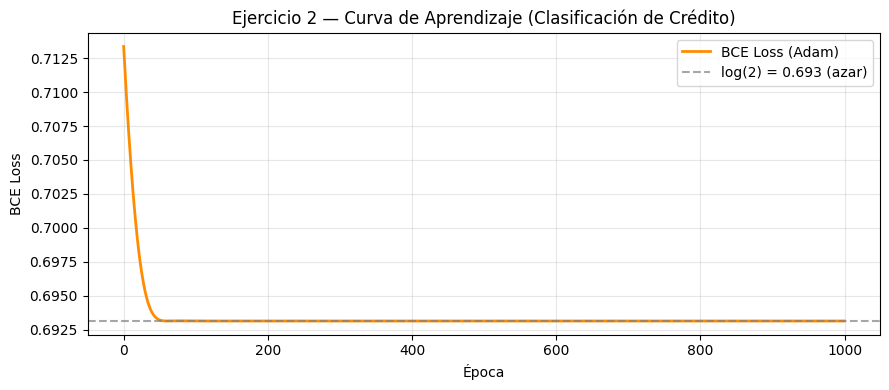

In [33]:
plt.figure(figsize=(9, 4))
plt.plot(historico_loss_ej2, color='darkorange', linewidth=2, label='BCE Loss (Adam)')
plt.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.7, label=f'log(2) = {np.log(2):.3f} (azar)')
plt.xlabel('Época'); plt.ylabel('BCE Loss')
plt.title('Ejercicio 2 — Curva de Aprendizaje (Clasificación de Crédito)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Tarea 5: Evaluación en el Test Set

Evalúa el modelo entrenado en el test set. Calcula la accuracy. Grafica la frontera de decisión.

In [ ]:
# TODO: Evaluación en test y frontera de decisión
# TU CÓDIGO AQUÍ

In [36]:
modelo_ej2 = RedCredito(n_hidden=3)
optimizador_ej2 = torch.optim.Adam(modelo_ej2.parameters(), lr=0.01)
criterio_ej2 = nn.BCELoss()

for epoca in range(N_EPOCAS_EJ2):
    modelo_ej2.train()
    optimizador_ej2.zero_grad()
    y_hat_ej2 = modelo_ej2(X_train_ej2)
    loss_ej2 = criterio_ej2(y_hat_ej2, y_train_ej2)
    loss_ej2.backward()
    optimizador_ej2.step()

modelo_ej2.eval()
with torch.no_grad():
    y_hat_test = modelo_ej2(X_test_ej2)
    y_pred_test = (y_hat_test >= 0.5).float()

print('Predicciones del modelo en el test set (primeros 5):')
print(f'y_hat_test:\n{y_hat_test.detach().cpu().numpy().round(4)}')
print(f'y_pred_test:\n{y_pred_test.int()}')

Predicciones del modelo en el test set (primeros 5):
y_hat_test:
[[0.0067]
 [0.0067]
 [0.014 ]
 [0.9967]
 [0.9998]]
y_pred_test:
tensor([[0],
        [0],
        [0],
        [1],
        [1]], dtype=torch.int32)


In [37]:
correctos = (y_pred_test == y_test_ej2).sum().item()
total = y_test_ej2.shape[0]
accuracy = correctos / total * 100

print('\nEvaluación en Test Set:')
print(f'{"i":>3} | {"x1":>6} {"x2":>6} | {"y_real":>7} | {"ŷ":>7} | {"ŷ_pred":>7} | Resultado')
print('-' * 55)
for i in range(total):
    yi = int(y_test_ej2[i, 0].item())
    yh = y_hat_test[i, 0].item()
    yp = int(y_pred_test[i, 0].item())
    resultado = '✓ CORRECTO' if yp == yi else '✗ INCORRECTO'
    print(f'{i+1:3d} | {X_test_ej2[i,0].item():.2f}  {X_test_ej2[i,1].item():.2f} | {yi:7d} | {yh:.4f} | {yp:7d} | {resultado}')

print(f'\nAccuracy en Test: {correctos}/{total} = {accuracy:.1f}%')



Evaluación en Test Set:
  i |     x1     x2 |  y_real |       ŷ |  ŷ_pred | Resultado
-------------------------------------------------------
  1 | 0.20  0.30 |       0 | 0.0067 |       0 | ✓ CORRECTO
  2 | 0.45  0.25 |       0 | 0.0067 |       0 | ✓ CORRECTO
  3 | 0.35  0.45 |       0 | 0.0140 |       0 | ✓ CORRECTO
  4 | 0.70  0.75 |       1 | 0.9967 |       1 | ✓ CORRECTO
  5 | 0.85  0.80 |       1 | 0.9998 |       1 | ✓ CORRECTO

Accuracy en Test: 5/5 = 100.0%


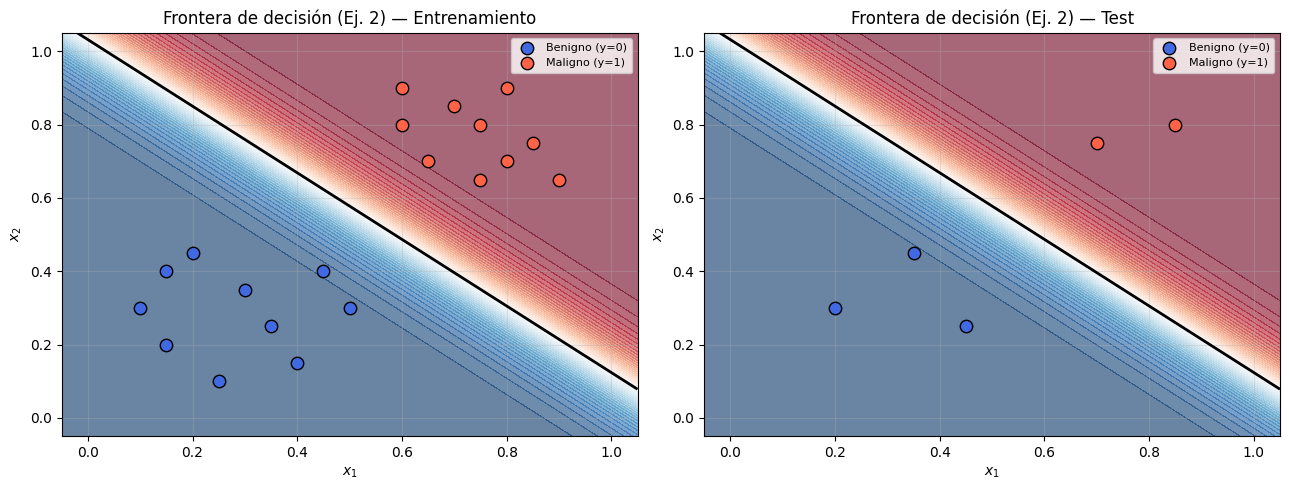

In [38]:
plot_decision_boundary(modelo_ej2, X_train_ej2, y_train_ej2, X_test_ej2, y_test_ej2, titulo='Frontera de decisión (Ej. 2)')

### Preguntas de Reflexión

Responde en las celdas de texto debajo de cada pregunta:

**P1.** ¿Cuántos parámetros tiene la red $2\to3\to1$ vs la red $2\to2\to1$ del Ejercicio 1? ¿Qué consecuencias tiene esto?

La red $2\to3\to1$ (Ejercicio 2) tiene 13 parámetros, y la red $2\to2\to1$ (Ejercicio 1) tiene 9 parámetros

Las consecuencias de tener un mayor o menor número de parámetros son:
* Una red con más parámetros tiene una mayor "capacidad" para aprender funciones complejas y no lineales. Esto significa que puede ajustarse mejor a datos complicados y potencialmente lograr una mayor precisión en el conjunto de entrenamiento. Una red con menos parámetros tiene una menor capacidad. Le costará más aprender patrones complejos y podría no ser capaz de modelar adecuadamente la relación en los datos, llevando a un underfitting (subajuste).
* En términos de recursos, un modelo de más parámetros requiere más memoria y tiempo de cómputo.

**P2.** ¿Por qué no se actualizan los pesos durante la evaluación del test? ¿Qué pasaría si sí se actualizaran?

Porque el objetivo de la fase de evaluación es medir la capacidad de generalización del modelo a datos que nunca ha visto, para saber qué tan bien el modelo predice en escenarios del mundo real, y no qué tan bien memoriza el conjunto de test.

Si se actualizaran los pesos, el modelo perdería su capacidad para generalizar a datos nuevos volviendose excesivamente especializado en el conjunto de test, perdiendo habilidad para manejar la variabilidad de nuevas estructuras de datos. Esto tambien invalidaría el conjunto de test como una referencia confiable

**P3.** Experimenta cambiando el número de neuronas ocultas a 1 y luego a 10. ¿Qué efecto tiene en la frontera de decisión y en la pérdida final?


Modelo con n_hidden=1: RedCredito(
  (fc1): Linear(in_features=2, out_features=1, bias=True)
  (fc2): Linear(in_features=1, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Parámetros totales (n_hidden=1): 5

Entrenando modelo con n_hidden=1 para 1000 épocas...
Época  200/1000 — Loss: 0.1837
Época  400/1000 — Loss: 0.0554
Época  600/1000 — Loss: 0.0264
Época  800/1000 — Loss: 0.0156
Época 1000/1000 — Loss: 0.0105

Loss inicial (n_hidden=1): 0.7881
Loss final (n_hidden=1): 0.0105
Accuracy en Test (n_hidden=1): 100.0%


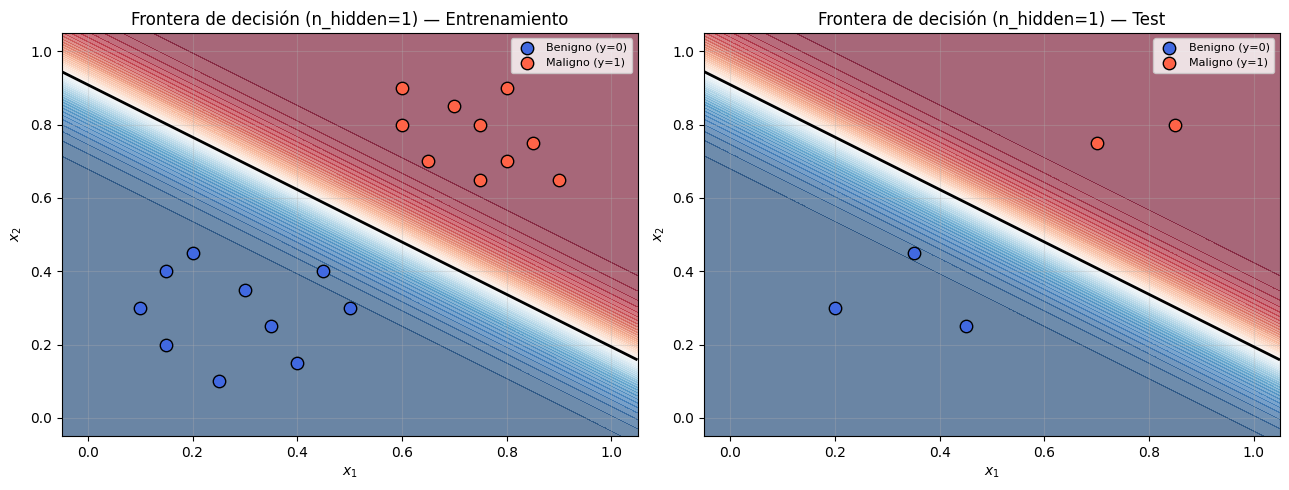

In [39]:
# TODO: Experimento con distintos tamaños de capa oculta
# TU CÓDIGO AQUÍ

# 1. Crea una nueva instancia de la clase RedCredito con n_hidden=1
print('\n--- Experimento con n_hidden=1 ---')
modelo_n1 = RedCredito(n_hidden=1)
print(f"\nModelo con n_hidden=1: {modelo_n1}")
print('Parámetros totales (n_hidden=1):', sum(param.numel() for param in modelo_n1.parameters()))

# 2. Define el criterio y el optimizador para este nuevo modelo
criterio_n1 = nn.BCELoss()
optimizador_n1 = torch.optim.Adam(modelo_n1.parameters(), lr=0.01)

N_EPOCAS_N1 = 1000
historico_loss_n1 = []

print(f"\nEntrenando modelo con n_hidden=1 para {N_EPOCAS_N1} épocas...")
for epoca in range(N_EPOCAS_N1):
    modelo_n1.train()
    optimizador_n1.zero_grad()
    y_hat_n1 = modelo_n1(X_train_ej2)
    loss_n1 = criterio_n1(y_hat_n1, y_train_ej2)
    loss_n1.backward()
    optimizador_n1.step()
    historico_loss_n1.append(loss_n1.item())

    if (epoca + 1) % 200 == 0:
        print(f'Época {epoca+1:4d}/{N_EPOCAS_N1} — Loss: {loss_n1.item():.4f}')

print(f'\nLoss inicial (n_hidden=1): {historico_loss_n1[0]:.4f}')
print(f'Loss final (n_hidden=1): {historico_loss_n1[-1]:.4f}')

# Evaluar en Test Set y calcular accuracy (opcional, pero buena práctica)
modelo_n1.eval()
with torch.no_grad():
    y_hat_test_n1 = modelo_n1(X_test_ej2)
    y_pred_test_n1 = (y_hat_test_n1 >= 0.5).float()

correctos_n1 = (y_pred_test_n1 == y_test_ej2).sum().item()
total_n1 = y_test_ej2.shape[0]
accuracy_n1 = correctos_n1 / total_n1 * 100
print(f'Accuracy en Test (n_hidden=1): {accuracy_n1:.1f}%')

# 4. Visualizar la frontera de decisión
plot_decision_boundary(modelo_n1, X_train_ej2, y_train_ej2, X_test_ej2, y_test_ej2, titulo='Frontera de decisión (n_hidden=1)')


--- Experimento con n_hidden=10 ---

Modelo con n_hidden=10: RedCredito(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Parámetros totales (n_hidden=10): 41

Entrenando modelo con n_hidden=10 para 1000 épocas...
Época  200/1000 — Loss: 0.0146
Época  400/1000 — Loss: 0.0038
Época  600/1000 — Loss: 0.0018
Época  800/1000 — Loss: 0.0010
Época 1000/1000 — Loss: 0.0007

Loss inicial (n_hidden=10): 0.7028
Loss final (n_hidden=10): 0.0007
Accuracy en Test (n_hidden=10): 100.0%


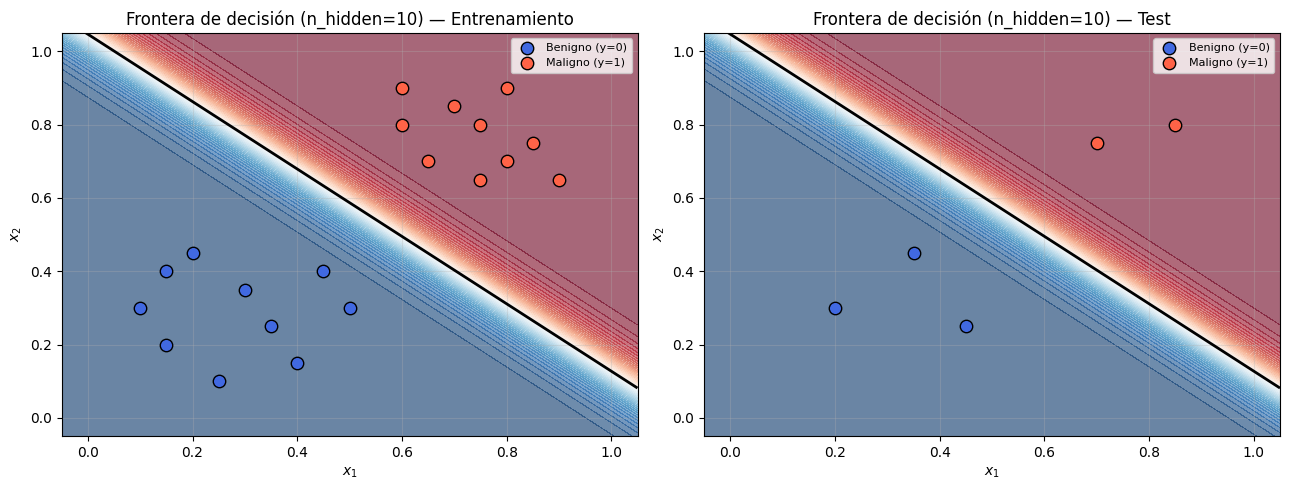

In [40]:
print('\n--- Experimento con n_hidden=10 ---')
# 1. Crea una nueva instancia de la clase RedCredito con n_hidden=10
modelo_n10 = RedCredito(n_hidden=10)
print(f"\nModelo con n_hidden=10: {modelo_n10}")
print('Parámetros totales (n_hidden=10):', sum(param.numel() for param in modelo_n10.parameters()))

# 2. Define el criterio y el optimizador para este nuevo modelo
criterio_n10 = nn.BCELoss()
optimizador_n10 = torch.optim.Adam(modelo_n10.parameters(), lr=0.01)

N_EPOCAS_N10 = 1000
historico_loss_n10 = []

print(f"\nEntrenando modelo con n_hidden=10 para {N_EPOCAS_N10} épocas...")
for epoca in range(N_EPOCAS_N10):
    modelo_n10.train()
    optimizador_n10.zero_grad()
    y_hat_n10 = modelo_n10(X_train_ej2)
    loss_n10 = criterio_n10(y_hat_n10, y_train_ej2)
    loss_n10.backward()
    optimizador_n10.step()
    historico_loss_n10.append(loss_n10.item())

    if (epoca + 1) % 200 == 0:
        print(f'Época {epoca+1:4d}/{N_EPOCAS_N10} — Loss: {loss_n10.item():.4f}')

print(f'\nLoss inicial (n_hidden=10): {historico_loss_n10[0]:.4f}')
print(f'Loss final (n_hidden=10): {historico_loss_n10[-1]:.4f}')

# 6. Evaluar en Test Set y calcular accuracy
modelo_n10.eval()
with torch.no_grad():
    y_hat_test_n10 = modelo_n10(X_test_ej2)
    y_pred_test_n10 = (y_hat_test_n10 >= 0.5).float()

correctos_n10 = (y_pred_test_n10 == y_test_ej2).sum().item()
total_n10 = y_test_ej2.shape[0]
accuracy_n10 = correctos_n10 / total_n10 * 100
print(f'Accuracy en Test (n_hidden=10): {accuracy_n10:.1f}%')

# 7. Visualizar la frontera de decisión
plot_decision_boundary(modelo_n10, X_train_ej2, y_train_ej2, X_test_ej2, y_test_ej2, titulo='Frontera de decisión (n_hidden=10)')
